# Training Loop & Model Debugging - Hands-On Lab**Learning Objectives:**- Implement complete PyTorch training loops- Use DataLoader for batching and shuffling- Tune batch size and learning rate- Interpret loss curves and detect overfitting- Inspect gradients for debugging- Save and load model checkpoints**Prerequisites:**- Basic PyTorch knowledge- Understanding of neural networks- Python programming skills

## Section 1: Setup and ImportsFirst, let's import all necessary libraries and set up our environment.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import numpy as np
import time

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
print("Setup complete!")

Using device: cpu
Setup complete!


## Section 2: Create Synthetic DatasetWe'll create a synthetic classification dataset to practice with.

In [3]:
# Create synthetic dataset
def create_classification_dataset(num_samples=5000, input_size=50, num_classes=5):
    """
    Create synthetic classification dataset.

    Args:
        num_samples: Number of samples
        input_size: Number of features
        num_classes: Number of classes

    Returns:
        TensorDataset
    """
    # Generate random features
    X = torch.randn(num_samples, input_size)

    # Generate labels with some structure
    # (makes it learnable, not completely random)
    weights = torch.randn(input_size, num_classes)
    logits = X @ weights
    y = torch.argmax(logits, dim=1)

    return TensorDataset(X, y)

# Create dataset
full_dataset = create_classification_dataset(num_samples=5000)

# Split into train (70%), validation (15%), test (15%)
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size])

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 3500
Validation samples: 750
Test samples: 750


## Exercise 1: Understanding DataLoader**Task:** Create DataLoaders with different batch sizes and observe the effects.**Instructions:**1. Create three DataLoaders with batch_size = 16, 64, and 2562. Print the number of batches per epoch for each3. Time one complete epoch for each batch size

In [4]:
# TODO: Create DataLoader with batch_size=16
train_loader_small = DataLoader(train_dataset, batch_size=16, shuffle=True)

# TODO: Create DataLoader with batch_size=64
train_loader_medium = DataLoader(train_dataset, batch_size=64, shuffle=True)

# TODO: Create DataLoader with batch_size=256
train_loader_large = DataLoader(train_dataset, batch_size=256, shuffle=True)

# Print information
print("Batch Size 16:")
print(f"  Batches per epoch: {len(train_loader_small)}")
print("\nBatch Size 64:")
print(f"  Batches per epoch: {len(train_loader_medium)}")
print("\nBatch Size 256:")
print(f"  Batches per epoch: {len(train_loader_large)}")

# TODO: Time one epoch for each loader
def time_epoch(loader):
    start = time.time()
    for data, labels in loader:
        pass  # Just iterate, don't train
    return time.time() - start

print("\nTime per epoch:")
print(f"  Batch 16:  {time_epoch(train_loader_small):.3f}s")
print(f"  Batch 64:  {time_epoch(train_loader_medium):.3f}s")
print(f"  Batch 256: {time_epoch(train_loader_large):.3f}s")

Batch Size 16:
  Batches per epoch: 219

Batch Size 64:
  Batches per epoch: 55

Batch Size 256:
  Batches per epoch: 14

Time per epoch:
  Batch 16:  0.052s
  Batch 64:  0.018s
  Batch 256: 0.015s


**Question:** What do you observe about the number of batches and speed?**Expected observation:** Larger batch sizes = fewer batches = faster epoch time (but uses more memory)

## Section 3: Define Neural NetworkLet's define a simple feedforward network for classification.

In [5]:
class SimpleClassifier(nn.Module):
    """Simple feedforward classifier."""

    def __init__(self, input_size=50, hidden_size=128, num_classes=5, dropout=0.2):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# Create model
model = SimpleClassifier(input_size=50, hidden_size=128, num_classes=5)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

SimpleClassifier(
  (network): Sequential(
    (0): Linear(in_features=50, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=5, bias=True)
  )
)

Total parameters: 15,109


## Exercise 2: Implement Basic Training Loop**Task:** Complete the training loop with the correct order of operations.**Instructions:**1. Fill in the missing steps in the training loop2. Make sure to follow the correct order: zero_grad → backward → step3. Track the loss for each batch

In [6]:
def train_one_epoch(model, train_loader, criterion, optimizer, device='cpu'):
    """
    Train for one epoch.

    Returns:
        average_loss: Average loss across all batches
    """
    model.train()  # Set to training mode
    total_loss = 0

    for batch_idx, (data, labels) in enumerate(train_loader):
        data, labels = data.to(device), labels.to(device)

        # Step 1: Forward pass
        outputs = model(data)
        loss = criterion(outputs, labels)

        # TODO: Step 2 - Zero gradients
        optimizer.zero_grad()

        # TODO: Step 3 - Backward pass
        loss.backward()

        # TODO: Step 4 - Update weights
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)
    return average_loss

# Setup training
model = SimpleClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Train for one epoch
loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
print(f"Training Loss: {loss:.4f}")

Training Loss: 1.4841


**Check:** If implemented correctly, you should see the loss decrease over multiple epochs.

## Exercise 3: Add Validation Function**Task:** Implement a validation function to evaluate the model.**Instructions:**1. Set model to eval mode2. Disable gradient computation with torch.no_grad()3. Calculate loss and accuracy

In [7]:
def validate(model, val_loader, criterion, device='cpu'):
    """
    Validate the model.

    Returns:
        avg_loss: Average validation loss
        accuracy: Validation accuracy (%)
    """
    # TODO: Set model to evaluation mode
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    # TODO: Disable gradient computation
    with torch.no_grad():
        for data, labels in val_loader:
            data, labels = data.to(device), labels.to(device)

            # Forward pass only
            outputs = model(data)
            loss = criterion(outputs, labels)

            # Track metrics
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(val_loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy

# Test validation function
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
val_loss, val_acc = validate(model, val_loader, criterion, device)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.2f}%")

Validation Loss: 1.2514
Validation Accuracy: 59.87%


## Exercise 4: Train with Loss Tracking**Task:** Train the model for multiple epochs and track losses.**Instructions:**1. Train for 20 epochs2. Track both training and validation losses3. Print progress every epoch

In [8]:
# Reset model
model = SimpleClassifier().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training configuration
num_epochs = 20
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Track history
train_losses = []
val_losses = []
val_accuracies = []

print("Starting training...")
print("="*60)

for epoch in range(num_epochs):
    # Train
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Store history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Print progress
    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}%")

print("="*60)
print("Training complete!")

Starting training...
Epoch  1/20 | Train Loss: 1.4700 | Val Loss: 1.2171 | Val Acc: 63.33%
Epoch  2/20 | Train Loss: 0.9063 | Val Loss: 0.5768 | Val Acc: 84.27%
Epoch  3/20 | Train Loss: 0.5003 | Val Loss: 0.3555 | Val Acc: 89.60%
Epoch  4/20 | Train Loss: 0.3669 | Val Loss: 0.2835 | Val Acc: 91.20%
Epoch  5/20 | Train Loss: 0.3157 | Val Loss: 0.2537 | Val Acc: 90.80%
Epoch  6/20 | Train Loss: 0.2656 | Val Loss: 0.2268 | Val Acc: 92.27%
Epoch  7/20 | Train Loss: 0.2375 | Val Loss: 0.2157 | Val Acc: 91.87%
Epoch  8/20 | Train Loss: 0.2089 | Val Loss: 0.2095 | Val Acc: 92.27%
Epoch  9/20 | Train Loss: 0.2017 | Val Loss: 0.1999 | Val Acc: 92.40%
Epoch 10/20 | Train Loss: 0.1898 | Val Loss: 0.2030 | Val Acc: 91.20%
Epoch 11/20 | Train Loss: 0.1937 | Val Loss: 0.2070 | Val Acc: 91.33%
Epoch 12/20 | Train Loss: 0.1633 | Val Loss: 0.1925 | Val Acc: 92.00%
Epoch 13/20 | Train Loss: 0.1574 | Val Loss: 0.1980 | Val Acc: 91.73%
Epoch 14/20 | Train Loss: 0.1464 | Val Loss: 0.1838 | Val Acc: 92.27%

## Exercise 5: Visualize Training Progress**Task:** Plot the loss curves to visualize training.**Instructions:**1. Plot both training and validation losses2. Add labels, title, and legend3. Identify if the model is overfitting

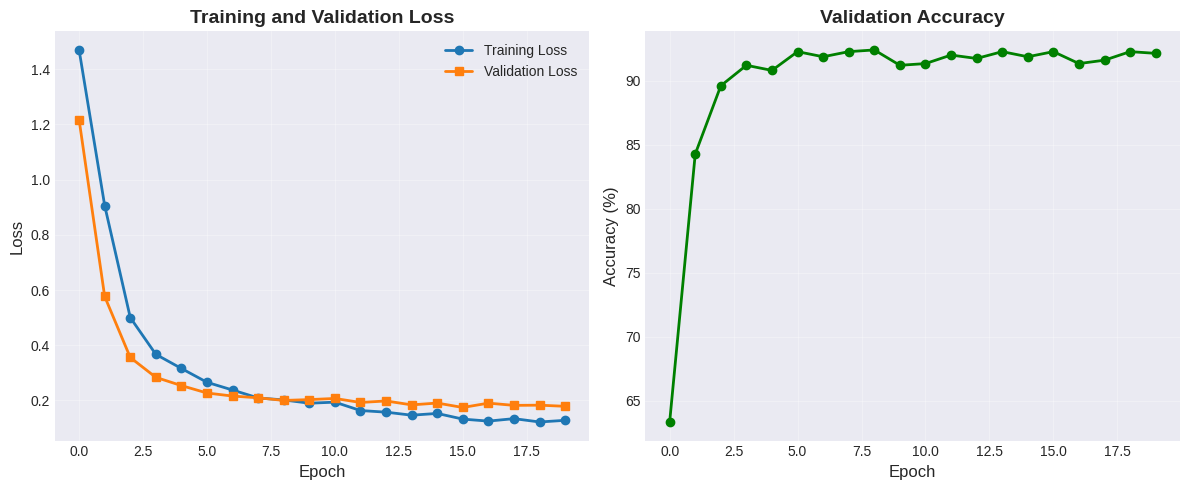


Best validation loss: 0.1744 at epoch 16


In [9]:
# TODO: Plot loss curves
plt.figure(figsize=(12, 5))

# Plot 1: Loss curves
plt.subplot(1, 2, 1)
plt.plot(train_losses, 'o-', label='Training Loss', linewidth=2)
plt.plot(val_losses, 's-', label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Validation accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, 'o-', linewidth=2, color='green')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Validation Accuracy', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find best epoch
best_epoch = np.argmin(val_losses) + 1
best_val_loss = min(val_losses)
print(f"\nBest validation loss: {best_val_loss:.4f} at epoch {best_epoch}")

**Question:** Based on the plots, is the model overfitting? Why or why not?**Answer:** Check if validation loss starts increasing while training loss continues decreasing. If yes, that's overfitting!

## Exercise 6: Learning Rate Experiments**Task:** Train models with different learning rates and compare results.**Instructions:**1. Train with learning rates: [0.1, 0.01, 0.001, 0.0001]2. Track validation loss for each3. Plot and identify the best learning rate


Training with LR=0.1
----------------------------------------
  Epoch 5: Val Loss=1.6073, Val Acc=22.93%
  Epoch 10: Val Loss=1.6255, Val Acc=22.93%
  Epoch 15: Val Loss=1.6106, Val Acc=22.93%

Training with LR=0.01
----------------------------------------
  Epoch 5: Val Loss=0.3317, Val Acc=86.40%
  Epoch 10: Val Loss=0.3443, Val Acc=87.73%
  Epoch 15: Val Loss=0.2960, Val Acc=90.27%

Training with LR=0.001
----------------------------------------
  Epoch 5: Val Loss=0.2426, Val Acc=91.20%
  Epoch 10: Val Loss=0.1886, Val Acc=92.13%
  Epoch 15: Val Loss=0.1755, Val Acc=92.67%

Training with LR=0.0001
----------------------------------------
  Epoch 5: Val Loss=1.4731, Val Acc=47.87%
  Epoch 10: Val Loss=1.0976, Val Acc=72.80%
  Epoch 15: Val Loss=0.7197, Val Acc=82.00%


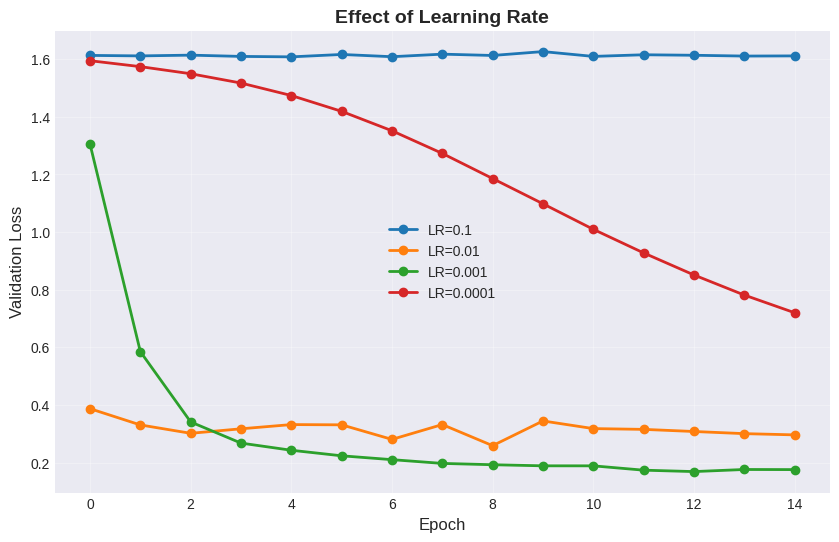

LR=0.1: Final Loss=1.6106, Best Loss=1.6073
LR=0.01: Final Loss=0.2960, Best Loss=0.2586
LR=0.001: Final Loss=0.1755, Best Loss=0.1686
LR=0.0001: Final Loss=0.7197, Best Loss=0.7197


In [10]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]
results = {}

for lr in learning_rates:
    print(f"\nTraining with LR={lr}")
    print("-"*40)

    # Reset model
    model = SimpleClassifier().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train for 15 epochs
    val_losses_lr = []
    for epoch in range(15):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        val_losses_lr.append(val_loss)

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}: Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")

    results[lr] = val_losses_lr

# Plot comparison
plt.figure(figsize=(10, 6))
for lr, losses in results.items():
    plt.plot(losses, 'o-', label=f'LR={lr}', linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Loss', fontsize=12)
plt.title('Effect of Learning Rate', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Find best learning rate
for lr, losses in results.items():
    final_loss = losses[-1]
    min_loss = min(losses)
    print(f"LR={lr}: Final Loss={final_loss:.4f}, Best Loss={min_loss:.4f}")

**Question:** Which learning rate works best? What happens with very high or very low learning rates?**Expected:** - Too high (0.1): Unstable or NaN- Too low (0.0001): Very slow convergence- Just right (0.001): Smooth, fast convergence

## Exercise 7: Inspect Gradients**Task:** Monitor gradient magnitudes during training.**Instructions:**1. Check gradient statistics after backward pass2. Identify vanishing or exploding gradients3. Visualize gradient distributions

In [11]:
def check_gradients(model):
    """Check gradient statistics for all parameters."""
    grad_stats = []

    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_abs = param.grad.abs()
            grad_mean = grad_abs.mean().item()
            grad_max = grad_abs.max().item()
            grad_min = grad_abs.min().item()

            grad_stats.append({
                'name': name,
                'mean': grad_mean,
                'max': grad_max,
                'min': grad_min
            })
    return grad_stats

# Train one batch and check gradients
model = SimpleClassifier().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
data, labels = next(iter(train_loader))
data, labels = data.to(device), labels.to(device)

# Forward and backward
outputs = model(data)
loss = criterion(outputs, labels)
optimizer.zero_grad()
loss.backward()

# Check gradients
grad_stats = check_gradients(model)
print("Gradient Statistics:")
print("="*70)
print(f"{'Layer':<30} {'Mean':>12} {'Max':>12} {'Min':>12}")
print("-"*70)
for stat in grad_stats:
    print(f"{stat['name']:<30} {stat['mean']:>12.2e} {stat['max']:>12.2e} {stat['min']:>12.2e}")
print("="*70)

# Check for problems
print("\nGradient Health Check:")
for stat in grad_stats:
    if stat['mean'] < 1e-7:
        print(f"  ⚠️ Warning: Vanishing gradients in {stat['name']}")
    elif stat['max'] > 10.0:
        print(f"  ⚠️ Warning: Exploding gradients in {stat['name']}")
    else:
        print(f"  ✓ Healthy gradients in {stat['name']}")

Gradient Statistics:
Layer                                  Mean          Max          Min
----------------------------------------------------------------------
network.0.weight                   1.74e-03     9.92e-03     1.60e-07
network.0.bias                     2.18e-03     9.24e-03     1.13e-06
network.3.weight                   2.60e-03     2.73e-02     0.00e+00
network.3.bias                     7.20e-03     3.53e-02     1.23e-04
network.6.weight                   1.22e-02     8.33e-02     3.14e-05
network.6.bias                     8.15e-02     1.46e-01     3.59e-02

Gradient Health Check:
  ✓ Healthy gradients in network.0.weight
  ✓ Healthy gradients in network.0.bias
  ✓ Healthy gradients in network.3.weight
  ✓ Healthy gradients in network.3.bias
  ✓ Healthy gradients in network.6.weight
  ✓ Healthy gradients in network.6.bias


**Question:** What is the typical range for healthy gradients?**Answer:** Typically 1e-5 to 1e-1. Outside this range may indicate problems.

## Exercise 8: Save and Load Checkpoints**Task:** Implement checkpoint saving during training.**Instructions:**1. Save checkpoints every 5 epochs2. Save the best model based on validation loss3. Load and test the best model

In [12]:
import os

# Create checkpoint directory
os.makedirs('checkpoints', exist_ok=True)

# Training with checkpoints
model = SimpleClassifier().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
best_val_loss = float('inf')
num_epochs = 20
print("Training with checkpoint saving...")
print("="*60)

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1:2d}/{num_epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    # Save checkpoint every 5 epochs
    if (epoch + 1) % 5 == 0:
        checkpoint_path = f'checkpoints/checkpoint_epoch_{epoch+1}.pth'
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss
        }, checkpoint_path)
        print(f"  💾 Saved checkpoint: {checkpoint_path}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss': best_val_loss
        }, 'checkpoints/best_model.pth')
        print(f"  ✓ New best model! Val Loss: {val_loss:.4f}")

print("="*60)
print(f"Best validation loss: {best_val_loss:.4f}")

# Load best model
checkpoint = torch.load('checkpoints/best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"\nLoaded best model from epoch {checkpoint['epoch']+1}")

# Test on test set
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

Training with checkpoint saving...
Epoch  1/20 | Train: 1.4690 | Val: 1.2052
  ✓ New best model! Val Loss: 1.2052
Epoch  2/20 | Train: 0.9027 | Val: 0.5733
  ✓ New best model! Val Loss: 0.5733
Epoch  3/20 | Train: 0.4822 | Val: 0.3466
  ✓ New best model! Val Loss: 0.3466
Epoch  4/20 | Train: 0.3634 | Val: 0.2699
  ✓ New best model! Val Loss: 0.2699
Epoch  5/20 | Train: 0.3059 | Val: 0.2470
  💾 Saved checkpoint: checkpoints/checkpoint_epoch_5.pth
  ✓ New best model! Val Loss: 0.2470
Epoch  6/20 | Train: 0.2621 | Val: 0.2372
  ✓ New best model! Val Loss: 0.2372
Epoch  7/20 | Train: 0.2422 | Val: 0.2042
  ✓ New best model! Val Loss: 0.2042
Epoch  8/20 | Train: 0.2305 | Val: 0.1982
  ✓ New best model! Val Loss: 0.1982
Epoch  9/20 | Train: 0.1998 | Val: 0.2010
Epoch 10/20 | Train: 0.1833 | Val: 0.1927
  💾 Saved checkpoint: checkpoints/checkpoint_epoch_10.pth
  ✓ New best model! Val Loss: 0.1927
Epoch 11/20 | Train: 0.1772 | Val: 0.1810
  ✓ New best model! Val Loss: 0.1810
Epoch 12/20 | Trai

## Exercise 9: Overfitting Detection and Prevention**Task:** Deliberately create overfitting and then fix it.**Instructions:**1. Train a model that overfits (large network, no regularization, many epochs)2. Observe the train-val loss gap3. Add dropout and train again to prevent overfitting

Part A: Training model that overfits...
Epoch 5: Train=0.0316, Val=0.2038, Gap=0.1722
Epoch 10: Train=0.0013, Val=0.2268, Gap=0.2255
Epoch 15: Train=0.0005, Val=0.2281, Gap=0.2276
Epoch 20: Train=0.0003, Val=0.2360, Gap=0.2357
Epoch 25: Train=0.0002, Val=0.2427, Gap=0.2425
Epoch 30: Train=0.0001, Val=0.2483, Gap=0.2482

Part B: Training with dropout to prevent overfitting...
Epoch 5: Train=0.2208, Val=0.2408, Gap=0.0199
Epoch 10: Train=0.1284, Val=0.2444, Gap=0.1160
Epoch 15: Train=0.0892, Val=0.2890, Gap=0.1999
Epoch 20: Train=0.0906, Val=0.3392, Gap=0.2486
Epoch 25: Train=0.0604, Val=0.3431, Gap=0.2826
Epoch 30: Train=0.0565, Val=0.3501, Gap=0.2936


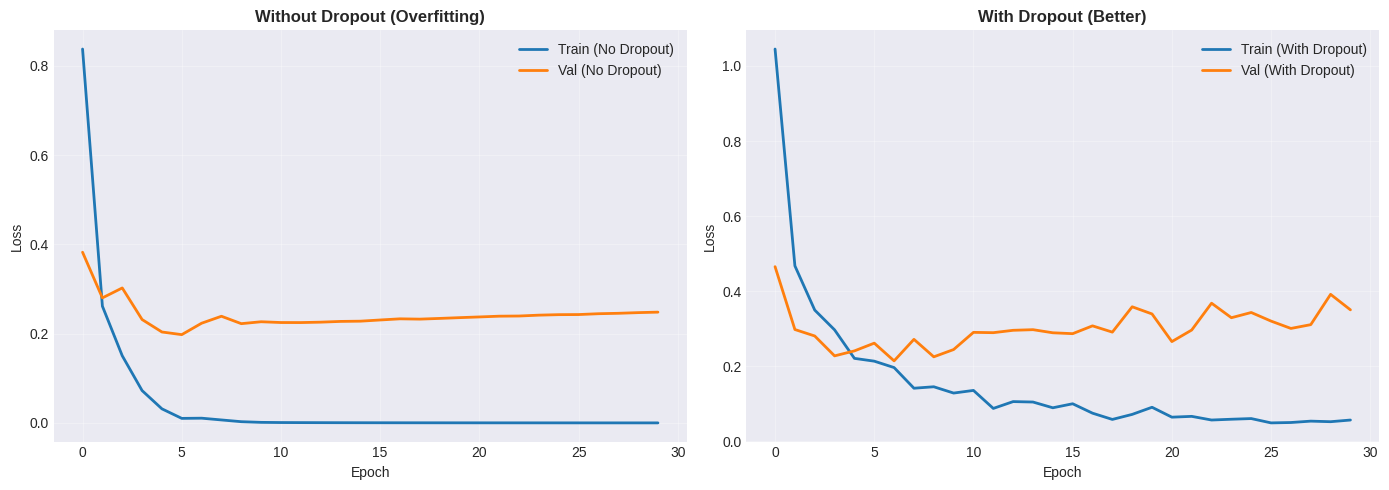


Final train-val gap:
  Without dropout: 0.2482
  With dropout: 0.2936
  Improvement: -0.0454


In [13]:
# Part A: Create overfitting model
print("Part A: Training model that overfits...")
print("="*60)

class LargeClassifier(nn.Module):
    """Large network prone to overfitting."""
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(50, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 5)
        )

    def forward(self, x):
        return self.network(x)

# Train without regularization
model_overfit = LargeClassifier().to(device)
optimizer = optim.Adam(model_overfit.parameters(), lr=0.001)
train_losses_overfit = []
val_losses_overfit = []

for epoch in range(30):
    train_loss = train_one_epoch(model_overfit, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model_overfit, val_loader, criterion, device)

    train_losses_overfit.append(train_loss)
    val_losses_overfit.append(val_loss)

    if (epoch + 1) % 5 == 0:
        gap = val_loss - train_loss
        print(f"Epoch {epoch+1}: Train={train_loss:.4f}, Val={val_loss:.4f}, Gap={gap:.4f}")

print("\nPart B: Training with dropout to prevent overfitting...")
print("="*60)

class RegularizedClassifier(nn.Module):
    """Network with dropout regularization."""
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(50, 512),
            nn.ReLU(),
            nn.Dropout(0.3),  # Add dropout!
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.3),  # Add dropout!
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),  # Add dropout!
            nn.Linear(256, 5)
        )

    def forward(self, x):
        return self.network(x)

# Train with regularization
model_reg = RegularizedClassifier().to(device)
optimizer = optim.Adam(model_reg.parameters(), lr=0.001)
train_losses_reg = []
val_losses_reg = []

for epoch in range(30):
    train_loss = train_one_epoch(model_reg, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model_reg, val_loader, criterion, device)

    train_losses_reg.append(train_loss)
    val_losses_reg.append(val_loss)

    if (epoch + 1) % 5 == 0:
        gap = val_loss - train_loss
        print(f"Epoch {epoch+1}: Train={train_loss:.4f}, Val={val_loss:.4f}, Gap={gap:.4f}")

# Compare results
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses_overfit, label='Train (No Dropout)', linewidth=2)
plt.plot(val_losses_overfit, label='Val (No Dropout)', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Without Dropout (Overfitting)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses_reg, label='Train (With Dropout)', linewidth=2)
plt.plot(val_losses_reg, label='Val (With Dropout)', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('With Dropout (Better)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate final gaps
gap_overfit = val_losses_overfit[-1] - train_losses_overfit[-1]
gap_reg = val_losses_reg[-1] - train_losses_reg[-1]

print(f"\nFinal train-val gap:")
print(f"  Without dropout: {gap_overfit:.4f}")
print(f"  With dropout: {gap_reg:.4f}")
print(f"  Improvement: {gap_overfit - gap_reg:.4f}")

## Summary

**What We Learned:**

1.  **DataLoader**: Efficient batching and shuffling
    -   Larger batches = fewer iterations = faster
    -   But use more memory
2.  **Training Loop**: Four critical steps
    -   `zero_grad()` → `backward()` → `step()`
    -   Order matters!
3.  **Loss Curves**: Detect issues early
    -   Both decreasing = good
    -   Train↓, Val↑ = overfitting
    -   Both flat = underfitting
4.  **Hyperparameters**:
    -   Batch size: 32-128 typical
    -   Learning rate: 0.001 (Adam), 0.01 (SGD)
5.  **Gradients**: Monitor health
    -   Healthy: 1e-5 to 1e-1
    -   < 1e-7 = vanishing
    -   > 1.0 = exploding
6.  **Checkpoints**: Save your work
    -   Periodic backups
    -   Best model
7.  **Overfitting Prevention**:
    -   Dropout
    -   Early stopping
    -   Weight decay

**Best Practices:**

-   Always validate after training
-   Track multiple metrics
-   Save checkpoints
-   Monitor gradients
-   Stop when validation stops improving

**Next Steps:**

-   Try on real datasets (MNIST, CIFAR-10)
-   Experiment with different architectures
-   Implement learning rate schedules
-   Add more regularization techniques